In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv("messy_housing_data.csv")

In [70]:
df

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.7,San Francisco
3,3358,2.0,4,1914.0,NaN,chicago
4,1624,2.0,5,1935.0,716945.96,New York City
...,...,...,...,...,...,...
415,3674,5.0,5,NaN,2664238.68,l.a.
416,939,3.0,5,1965.0,491056.77,Los Angeles
417,4880,3.0,3,2004.0,3709981.28,boston
418,3279,5.0,5,1935.0,1308383.3,Chicago


### Basic Understanding 

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_sqft   420 non-null    int64  
 1   bedrooms    399 non-null    float64
 2   bathrooms   420 non-null    int64  
 3   year_built  384 non-null    float64
 4   price       370 non-null    str    
 5   location    420 non-null    str    
dtypes: float64(2), int64(2), str(2)
memory usage: 19.8 KB


In [72]:
df.describe()

,area_sqft,bedrooms,bathrooms,year_built
count,420.000000,399.000000,420.00000,384.000000
mean,2621.888095,3.593985,3.02381,1960.197917
std,1330.825892,2.386218,1.45067,37.715887
min,-100.000000,1.000000,1.00000,1900.000000
25%,1462.500000,2.000000,2.00000,1926.000000
50%,2602.000000,3.000000,3.00000,1959.000000
75%,3709.000000,5.000000,4.00000,1994.000000
max,4999.000000,20.000000,5.00000,2026.000000


In [73]:
df.shape

(420, 6)

In [74]:
df.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price',
       'location'],
      dtype='str')

### Missing Values Analysis 

* Price column has 50 null values
* year_built 36
* bedrooms 21

In [75]:
df.isnull().sum().sort_values(ascending=False)

price         50
year_built    36
bedrooms      21
area_sqft      0
bathrooms      0
location       0
dtype: int64

In [76]:
df.isnull().sum().sort_values(ascending=False)

price         50
year_built    36
bedrooms      21
area_sqft      0
bathrooms      0
location       0
dtype: int64

In [77]:
df["price"]

0      2068779.98
1      1539208.46
2        557909.7
3             NaN
4       716945.96
          ...    
415    2664238.68
416     491056.77
417    3709981.28
418     1308383.3
419     496344.73
Name: price, Length: 420, dtype: str

### Handling Missing values

In [78]:
df["price"] = df["price"].replace(["N/A", "unavailable", "", " "], pd.NA)

In [79]:
df["price"] = pd.to_numeric(df["price"], errors='coerce')

In [80]:
median_price = df["price"].median()

In [81]:
df["price"] = df["price"].fillna(median_price)

In [82]:
df["price"].isna().sum()

np.int64(0)

In [83]:
df["price"] = df["price"].astype(int)

In [84]:
df

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779,austin
1,2017,6.0,4,2008.0,1539208,San Francisco
2,1592,3.0,3,1991.0,557909,San Francisco
3,3358,2.0,4,1914.0,1180883,chicago
4,1624,2.0,5,1935.0,716945,New York City
...,...,...,...,...,...,...
415,3674,5.0,5,NaN,2664238,l.a.
416,939,3.0,5,1965.0,491056,Los Angeles
417,4880,3.0,3,2004.0,3709981,boston
418,3279,5.0,5,1935.0,1308383,Chicago


In [85]:
df["location"].unique()

<StringArray>
[        'austin',  'San Francisco',        'chicago',  'New York City',
        'Chicago',          'miami',  'san francisco',             'LA',
           'l.a.',        'AUSTIN ',         'Austin',   'Los Angeles ',
            'La ',       'Chicago ',             'SF',         'boston',
         'Chicgo',            'nyc',         'Boston',    'Los Angeles',
    'los angeles',            'NYC',  'New York city',  'NEW YORK CITY',
   'LOS ANGELES ',        'Austin ',             'sf', 'San Francisco ',
           'L.A.',          'Miami',         'Bostan',        'Boston ',
         'Miami ',  'SAN FRANCISCO',          'L.A. ',            'Sf ',
 'New York City ',         'BOSTON',       'CHICAGO ',           'Nyc ',
        'CHICAGO',         'AUSTIN',          'MIAMI']
Length: 43, dtype: str

### We will need to clean this location column as this column is very messy

In [86]:
df["location"] = df["location"].str.lower().str.strip()

In [87]:
location_map = {
    "sf": "san francisco",
    "s.f.": "san francisco",
    "san francisco": "san francisco",
    "l.a.": "los angeles",
    "la": "los angeles",
    "l.a": "los angeles",
    "los angeles": "los angeles",
    "nyc": "new york city",
    "new york": "new york city",
    "new york city": "new york city",
    "chicgo": "chicago",
    "chicago": "chicago",
    "bostan": "boston",
    "boston": "boston",
    "austin": "austin"
}

df["location"] = df["location"].replace(location_map)

In [88]:
df["location"].unique()

<StringArray>
[       'austin', 'san francisco',       'chicago', 'new york city',
         'miami',   'los angeles',        'boston']
Length: 7, dtype: str

In [89]:
df

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779,austin
1,2017,6.0,4,2008.0,1539208,san francisco
2,1592,3.0,3,1991.0,557909,san francisco
3,3358,2.0,4,1914.0,1180883,chicago
4,1624,2.0,5,1935.0,716945,new york city
...,...,...,...,...,...,...
415,3674,5.0,5,NaN,2664238,los angeles
416,939,3.0,5,1965.0,491056,los angeles
417,4880,3.0,3,2004.0,3709981,boston
418,3279,5.0,5,1935.0,1308383,chicago


In [90]:
df.isna().sum().sort_values(ascending=True)

area_sqft      0
bathrooms      0
location       0
price          0
bedrooms      21
year_built    36
dtype: int64

In [91]:
missing_rows = df["bedrooms"].isna() | df["year_built"].isna()
percent_missing = missing_rows.sum() / len(df) * 100
print(percent_missing)

12.857142857142856


In [92]:
len(df)

420

### Since 12% is not too high and filling the bedrooms and year built with any kind of missing values i think will lead to complications so i am choosing to drop these missing values for a good model

In [93]:
df = df.dropna(subset=["bedrooms", "year_built"])

In [94]:
print("Remaining Rows", len(df))

Remaining Rows 366


In [95]:
df

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779,austin
1,2017,6.0,4,2008.0,1539208,san francisco
2,1592,3.0,3,1991.0,557909,san francisco
3,3358,2.0,4,1914.0,1180883,chicago
4,1624,2.0,5,1935.0,716945,new york city
...,...,...,...,...,...,...
414,1724,2.0,2,1912.0,851969,miami
416,939,3.0,5,1965.0,491056,los angeles
417,4880,3.0,3,2004.0,3709981,boston
418,3279,5.0,5,1935.0,1308383,chicago


In [96]:
location_dummies = pd.get_dummies(df["location"], prefix="loc")

In [97]:
df = pd.concat([df, location_dummies], axis=1)

In [98]:
df = df.drop(columns=["location"])

In [99]:
df

,area_sqft,bedrooms,bathrooms,year_built,price,loc_austin,loc_boston,loc_chicago,loc_los angeles,loc_miami,loc_new york city,loc_san francisco
0,2696,4.0,1,1962.0,2068779,True,False,False,False,False,False,False
1,2017,6.0,4,2008.0,1539208,False,False,False,False,False,False,True
2,1592,3.0,3,1991.0,557909,False,False,False,False,False,False,True
3,3358,2.0,4,1914.0,1180883,False,False,True,False,False,False,False
4,1624,2.0,5,1935.0,716945,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
414,1724,2.0,2,1912.0,851969,False,False,False,False,True,False,False
416,939,3.0,5,1965.0,491056,False,False,False,True,False,False,False
417,4880,3.0,3,2004.0,3709981,False,True,False,False,False,False,False
418,3279,5.0,5,1935.0,1308383,False,False,True,False,False,False,False


In [100]:
df.corr()

,area_sqft,bedrooms,bathrooms,year_built,price,loc_austin,loc_boston,loc_chicago,loc_los angeles,loc_miami,loc_new york city,loc_san francisco
area_sqft,1.000000,0.041359,-0.027377,0.048449,0.662579,-0.002597,0.113677,0.031318,-0.040497,0.025686,0.044893,-0.132211
bedrooms,0.041359,1.000000,-0.003461,0.008356,0.063023,0.042400,0.044939,-0.079124,0.028394,-0.034253,0.005039,-0.015833
bathrooms,-0.027377,-0.003461,1.000000,-0.088036,-0.056309,0.004473,0.052138,0.027706,0.029997,-0.030590,-0.061056,-0.017713
year_built,0.048449,0.008356,-0.088036,1.000000,0.071246,0.042617,0.070012,-0.088438,0.038475,-0.078318,-0.036433,0.030908
price,0.662579,0.063023,-0.056309,0.071246,1.000000,0.141761,0.037406,-0.005538,-0.029172,-0.038617,-0.003554,-0.086698
loc_austin,-0.002597,0.042400,0.004473,0.042617,0.141761,1.000000,-0.139643,-0.143450,-0.184408,-0.119599,-0.175826,-0.199596
loc_boston,0.113677,0.044939,0.052138,0.070012,0.037406,-0.139643,1.000000,-0.129593,-0.166595,-0.108046,-0.158842,-0.180316
loc_chicago,0.031318,-0.079124,0.027706,-0.088438,-0.005538,-0.143450,-0.129593,1.000000,-0.171137,-0.110992,-0.163173,-0.185232
loc_los angeles,-0.040497,0.028394,0.029997,0.038475,-0.029172,-0.184408,-0.166595,-0.171137,1.000000,-0.142682,-0.209762,-0.238120
loc_miami,0.025686,-0.034253,-0.030590,-0.078318,-0.038617,-0.119599,-0.108046,-0.110992,-0.142682,1.000000,-0.136042,-0.154434


In [101]:
df.isna().sum()

area_sqft            0
bedrooms             0
bathrooms            0
year_built           0
price                0
loc_austin           0
loc_boston           0
loc_chicago          0
loc_los angeles      0
loc_miami            0
loc_new york city    0
loc_san francisco    0
dtype: int64

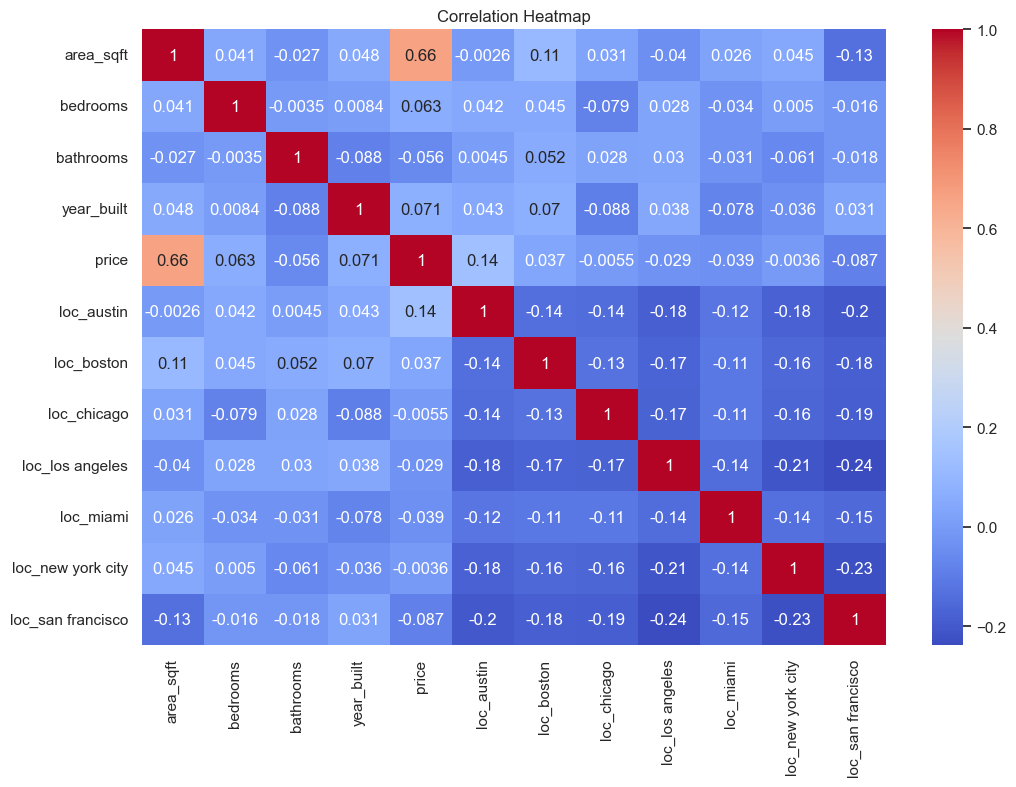

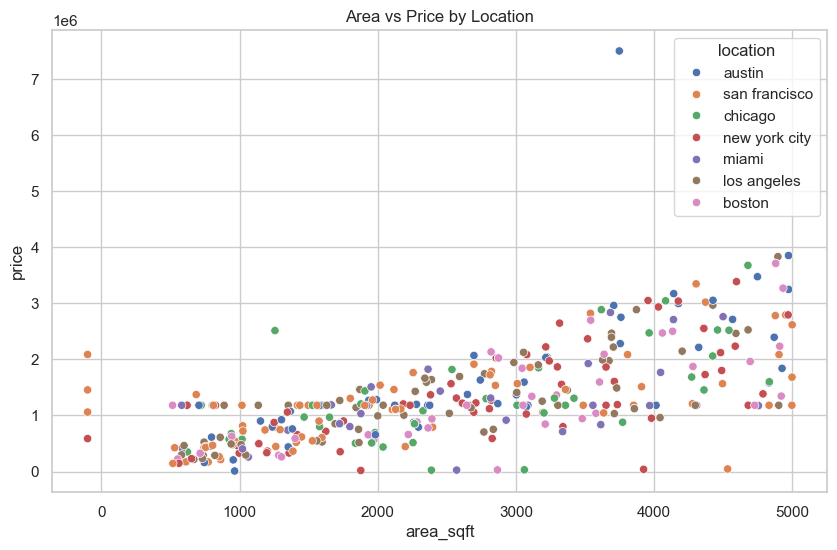

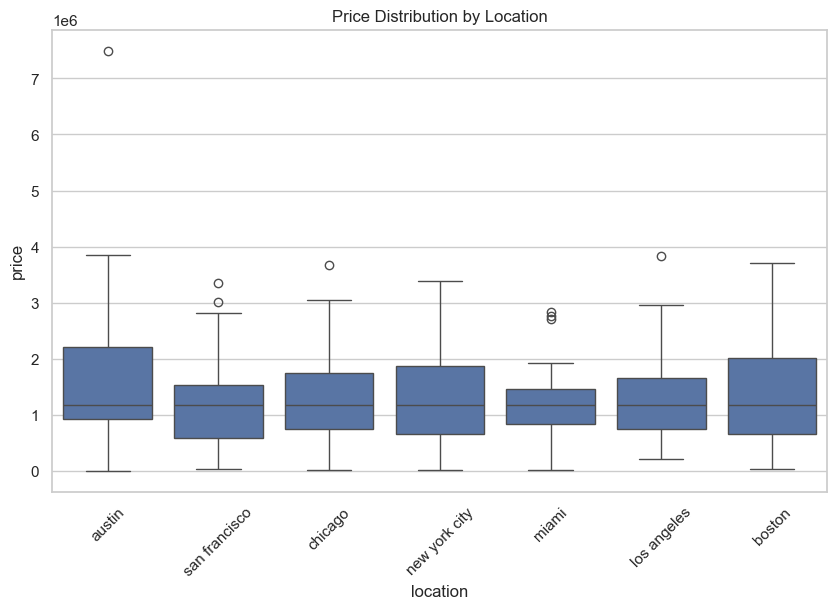

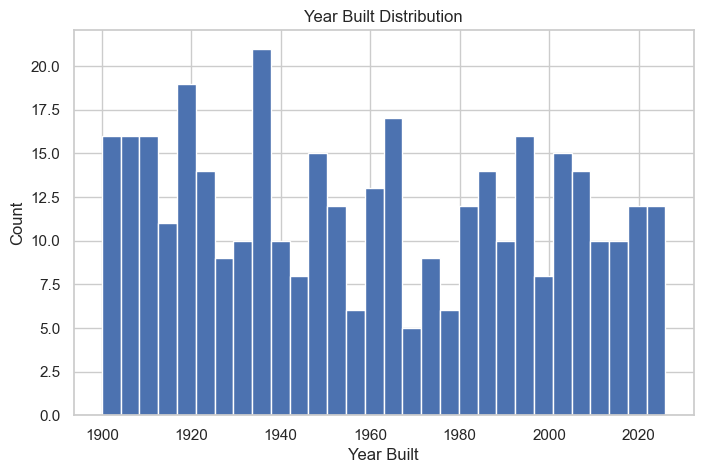

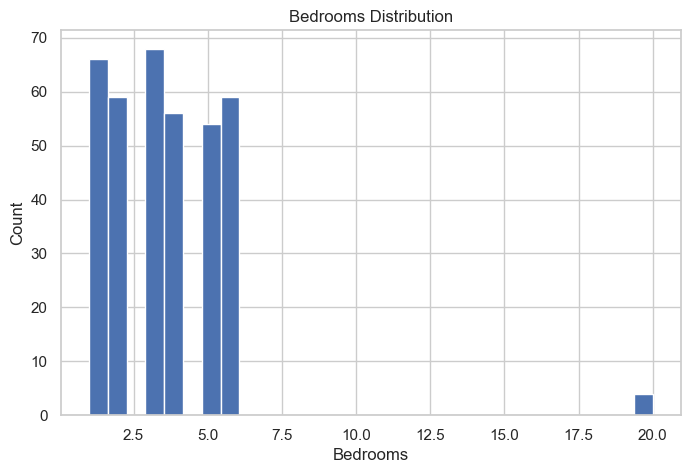

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set save path
save_path = r"C:/Users/Zenil/Desktop/EDA Eday/Day 2"

# Ensure directory exists
os.makedirs(save_path, exist_ok=True)

# --- Correlation Heatmap ---
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig(os.path.join(save_path, "correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Scatterplot: Area vs Price ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="area_sqft", y="price", hue="location")
plt.title("Area vs Price by Location")
plt.savefig(os.path.join(save_path, "scatter_area_price.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Boxplot: Price by Location ---
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="location", y="price")
plt.xticks(rotation=45)
plt.title("Price Distribution by Location")
plt.savefig(os.path.join(save_path, "boxplot_price_location.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Histogram: Year Built ---
plt.figure(figsize=(8,5))
df['year_built'].hist(bins=30)
plt.title("Year Built Distribution")
plt.xlabel("Year Built")
plt.ylabel("Count")
plt.savefig(os.path.join(save_path, "hist_year_built.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Histogram: Bedrooms ---
plt.figure(figsize=(8,5))
df['bedrooms'].hist(bins=30)
plt.title("Bedrooms Distribution")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.savefig(os.path.join(save_path, "hist_bedrooms.png"), dpi=300, bbox_inches="tight")
plt.show()

In [103]:
import os
print(os.getcwd())

C:\Users\Zenil\Desktop\EDA Eday\Day 2


### Inferences from above visuals -


📊 Boxplot: Price Distribution by Location
- Austin shows extreme variability — it has the widest range and the highest outlier, suggesting a mix of both affordable and ultra-luxury properties.
- San Francisco and Los Angeles cluster higher — their medians are elevated compared to cities like Chicago or Boston, confirming that location is a strong driver of price.

🔥 Correlation Heatmap
- Area vs Price is strongly correlated (≈0.66) — larger homes consistently command higher prices, making area_sqft a key predictor.
- Bedrooms and bathrooms show weaker correlations — they matter, but not nearly as much as area. Location dummies also show moderate correlations, reinforcing that city choice impacts price.

🛏 Bedrooms Distribution
- Most homes fall between 2–5 bedrooms — this is the “normal” housing stock, so models will learn best from this range.
- Outlier at 20 bedrooms — rare, extreme properties exist but could distort regression. You may want to cap or remove such outliers for cleaner modeling.


🏗 Year Built Distribution
- Peaks around 1940s and 1960s — construction activity surged in those decades, meaning many homes in the dataset are mid-century builds.
- Recent builds are fewer — fewer modern properties may limit the model’s ability to learn strong signals from year_built, but older homes could correlate with lower prices depending on location.

📈 Scatterplot: Area vs Price by Location
- Clear upward trend — as area_sqft increases, price rises, but the slope differs by city. San Francisco and Los Angeles points cluster higher even for smaller areas.
- City-specific separation — New York City and San Francisco homes are consistently more expensive at similar sizes compared to Chicago or Boston, showing that location interacts with area in driving price.

✅ Overall takeaway:
- area_sqft is your strongest continuous predictor.
- location (via one-hot encoding) adds significant explanatory power.
- Outliers (like 20 bedrooms or ultra-luxury Austin homes) should be handled carefully to avoid skewing the model.
- year_built and bedrooms provide secondary signals but are less dominant than area and location.
